# 07 — Final Comparison

Aggregates every method's saved metrics into one table and bar chart. Run
this last, after notebooks 02–06.

In [1]:
import sys
from pathlib import Path

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(REPO_ROOT) not in sys.path:
    sys.path.append(str(REPO_ROOT))

import json

import matplotlib.pyplot as plt
import pandas as pd

from utils import config

In [2]:
result_files = sorted(config.RESULTS_DIR.glob("metrics_*.json"))
assert len(result_files) > 0, "No results found — run notebooks 02-06 first"

rows = {}
for path in result_files:
    name = path.stem.replace("metrics_", "")
    with open(path) as f:
        data = json.load(f)

    if "test_metrics" in data:  # pseudo-labeling nests its results
        flat = {**data["test_metrics"], "Coverage": data["label_quality"]["Coverage"]}
    else:
        flat = data
    rows[name] = flat

# OpenAI-embedding-based methods are skipped upstream (notebook 02) when no
# API key/cache is available yet (e.g. billing not set up) — show them as
# "pending" in the comparison rather than silently omitting them.
OPENAI_METHODS = ["openai_kmeans", "openai_hdbscan"]
for method in OPENAI_METHODS:
    if method not in rows:
        rows[method] = {"Status": "pending"}

In [3]:
# Three real result schemas exist: unsupervised clustering (headline key
# "ACC (Hungarian)"), semisupervised classification ("Accuracy" — note
# full_supervised has no "Coverage", so checking for the full
# UNSUPERVISED_KEYS/SEMISUPERVISED_KEYS sets is too strict), and label-quality
# ("Label Accuracy", e.g. weak_supervision). Recognize any of the three.
CORE_KEYS = ["ACC (Hungarian)", "Accuracy", "Label Accuracy"]

for name, metrics in rows.items():
    if metrics.get("Status") == "pending":
        continue  # OpenAI placeholder rows carry no metrics yet
    assert any(k in metrics for k in CORE_KEYS), \
        f"'{name}' doesn't match any recognized metrics schema — got {list(metrics.keys())}"

df_results = pd.DataFrame(rows).T
config.RESULTS_DIR.mkdir(parents=True, exist_ok=True)
df_results.to_csv(config.RESULTS_DIR / "comparison_table.csv")
print(df_results.to_markdown())

|                         |   ACC (Hungarian) |    Macro F1 |          NMI |           ARI |        FMI |   Homogeneity |   Completeness |    V-Measure |   Silhouette Score |   Davies-Bouldin |   Coverage |   Accuracy |   Weighted F1 |   Macro Precision |   Macro Recall |   Cohen's Kappa |   Label Accuracy |   Label Macro F1 |   Mean Confidence |   Median Confidence |   mean_true_label_score | Status   |
|:------------------------|------------------:|------------:|-------------:|--------------:|-----------:|--------------:|---------------:|-------------:|-------------------:|-----------------:|-----------:|-----------:|--------------:|------------------:|---------------:|----------------:|-----------------:|-----------------:|------------------:|--------------------:|------------------------:|:---------|
| bertopic                |         0.71656   |   0.623077  |   0.660569   |   0.612686    |   0.739183 |    0.583221   |      0.761571  |   0.660569   |          0.0738334 |         4

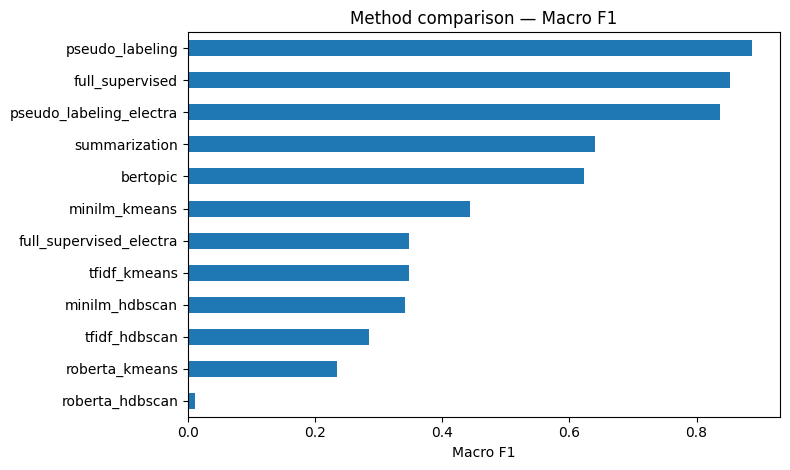

In [4]:
metric_to_plot = "Macro F1" if "Macro F1" in df_results.columns else "ACC (Hungarian)"
plot_df = df_results[metric_to_plot].dropna().sort_values()

fig, ax = plt.subplots(figsize=(8, max(4, 0.4 * len(plot_df))))
plot_df.plot(kind="barh", ax=ax)
ax.set_xlabel(metric_to_plot)
ax.set_title(f"Method comparison — {metric_to_plot}")
plt.tight_layout()
plt.savefig(config.RESULTS_DIR / "comparison_bar_chart.png", dpi=150)
plt.show()